In [1]:
                               **RICE LEAF DISEASE DETECTION PROJECT**


**Name  : P.Induja**
**Project ID: PTID-CDS-FEB-26-4032**
**Contribution: Individual**


Tools and Technologies:
Tool / Technology	                  Purpose

Python	                     Programming language
Jupyter Notebook	         Development environment
NumPy	                     Numerical operations
Pandas	                     Data analysis
OpenCV	                     Image processing
Matplotlib	                 Data visualization
Scikit-learn	             Machine learning utilities
TensorFlow / Keras	         Deep learning model development


#INTRODUCTION#

         Rice is one of the most staple crop in the world which plays a vital role in the world food security.
However rice crops are most susceptible to various disease. This diseases affects the crop yeild and quality.
Early detection of these diseases is essential for effective crop management and to minimize agricultural losses.
Traditional methos rely on manual inspection which is time consuming and inaccurate diagnosis.With the advancement 
of technology, machine learning and deep learning techniques have become powerful tools for automated disease detection
in plants. 

          In this project, a deep learning-based image classification model is developed to identify major rice leaf diseases 
using leaf images. The dataset consists of images categorized into three classes: Leaf Smut, Brown Spot, and Bacterial Leaf Blight.
 A Convolutional Neural Network (CNN) model is trained to analyze the patterns, textures, and color variations present in the leaf images 
in order to classify the diseases accurately.

**Objective of the Project**

The main objective of this project is to develop an automated system that can accurately detect and classify major rice leaf diseases 
using image processing and deep learning techniques. Rice crops are often affected by various diseases that can reduce crop yield and quality,
making early detection extremely important for effective crop management.

This project aims to build a Convolutional Neural Network (CNN) model that can analyze images of rice leaves and classify them into three 
disease categories: Leaf Smut, Brown Spot, and Bacterial Leaf Blight. The model will learn patterns, textures, and color variations present 
in the leaf images to identify the disease type.

he goal is to create a reliable machine learning solution that can assist farmers and agricultural experts in detecting rice leaf diseases at an early stage, 
helping to improve crop health, increase productivity, and reduce agricultural losses.

In [ ]:
**Data Analysis**

Data analysis is an important step in any machine learning project as it helps to understand the dataset, its structure, 
distribution, and potential challenges before building the model.

Dataset Overview

The dataset used in this project consists of images of rice leaves affected by different diseases. 
These images are categorized into three classes based on the type of disease present on the leaf.

The three classes in the dataset are:

*Leaf Smut
*Brown Spot
*Bacterial Leaf Blight

Each class contains 40 images, resulting in a total of 120 images in the dataset.

Disease Type	             Number of Images
Leaf Smut	                      40
Brown Spot	                      40
Bacterial Leaf Blight	          40
Total Images	                  120

This indicates that the dataset is balanced, meaning each class has an equal number of images.
Balanced datasets help prevent bias during model training.

In [6]:
                                         **DATA ANALYSIS**

#IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [37]:
pip install opencv-python

In [3]:
dataset_path = r"C:\Users\Induja\OneDrive\Desktop\Rice leaf"
classes = os.listdir(dataset_path)
print("Classes:", classes)

Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [36]:
pip install tensorflow


In [7]:
# COUNTING THE LENGTH OF THE DATA


for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, len(os.listdir(path)))


Bacterial leaf blight 40
Brown spot 40
Leaf smut 39


In [ ]:
**Data Visualization**

Sample images from each class were visualized to understand the visible differences between the diseases.

Leaf Smut: Appears as dark black fungal spots on the leaf surface.

Brown Spot: Characterized by brown circular lesions on the leaf.

Bacterial Leaf Blight: Shows yellowish or whitish streaks along the leaf edges.

Visualizing images helps in understanding how the model can learn different patterns and textures to distinguish between diseases.

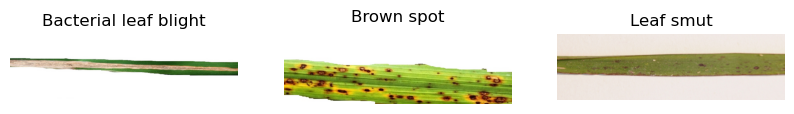

In [8]:
# DATA VISUALIZATION

import random

plt.figure(figsize=(10,6))

for i,cls in enumerate(classes):
    img_path = os.path.join(dataset_path, cls, random.choice(os.listdir(os.path.join(dataset_path,cls))))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [9]:
**REPORT FOR DATA VISUALIZATION**

#Here we can see the different affected leaves which shows the stripes, spots and dark spots.
#As the image are in different size now the data should be resized for consistent shape as the CNN needs one consistent shape.



In [ ]:
**DATA PREPROCESSING**

Before training the model, several preprocessing steps were applied:

*Image Resizing
All images were resized to 128 × 128 pixels to ensure uniform input size for the model.

*Normalization
Pixel values were scaled from 0–255 to 0–1 to improve training efficiency.

*Label Encoding
Disease labels were converted from categorical text values into numerical values so the model can process them.

*Train-Test Split
The dataset was divided into training data (80%) and testing data (20%) to evaluate model performance.

In [10]:
**RESIZING THE IMAGES**

In [11]:
IMG_SIZE = 128

data = []
labels = []

for cls in classes:
    path = os.path.join(dataset_path, cls)
    
    for img in os.listdir(path):
        image = cv2.imread(os.path.join(path,img))
        image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))
        
        data.append(image)
        labels.append(cls)

data = np.array(data)/255.0
labels = np.array(labels)

In [12]:
#LABEL ENCODER

from sklearn.preprocessing import LabelEncoder
laben = LabelEncoder()

labels = laben.fit_transform(labels)

In [13]:
#TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [15]:
X_train.shape

(95, 128, 128, 3)

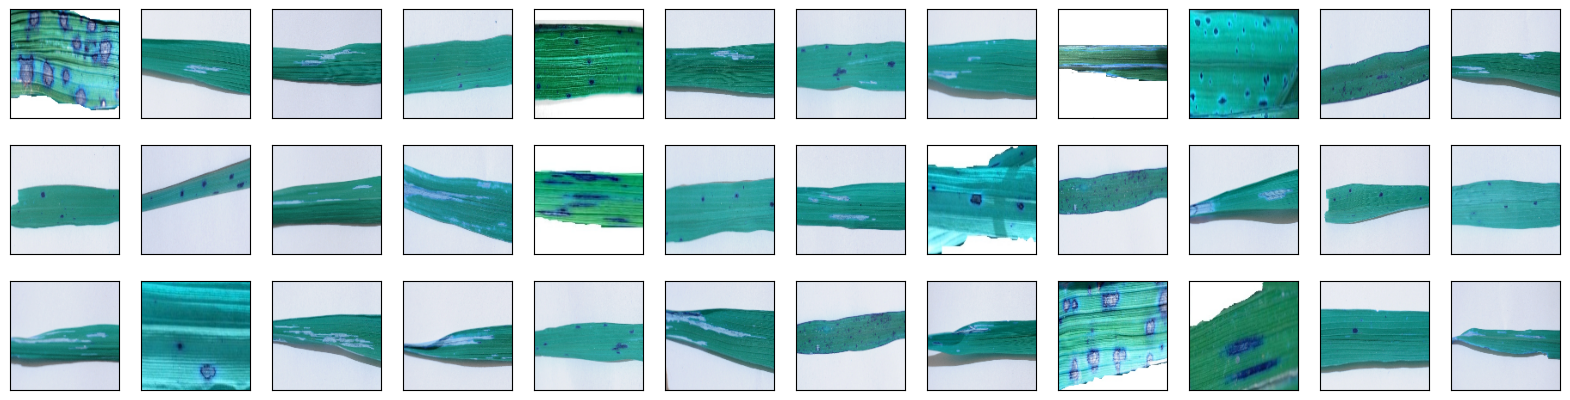

In [16]:
fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_train[i]))

In [17]:
X_train

array([[[[0.16078431, 0.61176471, 0.76862745],
         [0.05882353, 0.45882353, 0.59215686],
         [0.02352941, 0.36862745, 0.43529412],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[0.02352941, 0.47843137, 0.58039216],
         [0.11764706, 0.45882353, 0.5254902 ],
         [0.19607843, 0.56470588, 0.56470588],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[0.19607843, 0.61568627, 0.63529412],
         [0.17254902, 0.56862745, 0.54509804],
         [0.14509804, 0.52941176, 0.47058824],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        ...,

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]

In [18]:
Y_train


NameError: name 'Y_train' is not defined

In [19]:
y_train


array([1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0, 1, 2, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0, 0, 0, 2, 0,
       0, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1,
       0, 2, 1, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0,
       1, 1, 2, 0, 2, 1, 2])

In [ ]:
**CNN MODEL IMPLEMENTATION**

In this project, a Convolutional Neural Network (CNN) model was implemented to classify rice leaf images into three disease
categories: Leaf Smut, Brown Spot, and Bacterial Leaf Blight. CNNs are widely used in image classification tasks because they
are capable of automatically extracting important features such as edges, textures, and patterns from images.The CNN model was 
built using TensorFlow and the Keras library. The architecture of the model consists of multiple convolutional layers, 
pooling layers, and fully connected layers to effectively learn the features from the rice leaf images.

**Model Architecture**

The model architecture includes the following layers:

Convolutional Layers:
Convolutional layers are responsible for extracting important features from the input images using filters. In this model, multiple convolutional layers were used with increasing filter sizes (32, 64, and 128) to capture complex patterns in the images.

Max Pooling Layers:
Max pooling layers were used after convolutional layers to reduce the spatial dimensions of the feature maps. This helps in reducing computational complexity and retaining the most important features.

Flatten Layer:
The flatten layer converts the two-dimensional feature maps obtained from convolutional layers into a one-dimensional vector. This allows the data to be passed to fully connected layers.

Dense (Fully Connected) Layers:
Dense layers perform the final classification based on the extracted features. A dense layer with 128 neurons and ReLU activation was used to learn complex feature relationships.

Dropout Layer:
A dropout layer with a rate of 0.5 was added to reduce overfitting by randomly disabling neurons during training.

Output Layer:
The final dense layer contains 3 neurons corresponding to the three disease classes. A softmax activation function was used to convert the outputs into probability values for classification.

Model Compilation

The model was compiled using the following parameters:

Optimizer: Adam optimizer was used to efficiently update the network weights during training.

Loss Function: Sparse categorical crossentropy was used because the problem involves multi-class classification with integer labels.

Evaluation Metric: Accuracy was used to measure the performance of the model.

Model Training:

The CNN model was trained using the training dataset for 20 epochs. During training, the model learns patterns from the images 
and adjusts its weights to minimize prediction errors. Validation data was also used during training to monitor the model's 
performance on unseen data.

Purpose of CNN in This Project:

The CNN model automatically learns the distinguishing visual features of rice leaf diseases such as:

*Brown spots on the leaf surface

*Dark fungal patches

*Yellow streaks caused by bacterial infection

By learning these patterns, the model can accurately classify new rice leaf images into the correct disease category.

In [20]:

#CNN MODEL IMPLEMENTATION


model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Induja\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test,y_test)
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3263 - loss: 1.2050 - val_accuracy: 0.3750 - val_loss: 1.0930
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 947ms/step - accuracy: 0.4105 - loss: 1.1093 - val_accuracy: 0.4583 - val_loss: 1.0729
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 742ms/step - accuracy: 0.4632 - loss: 1.0642 - val_accuracy: 0.4167 - val_loss: 1.0367
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 806ms/step - accuracy: 0.4842 - loss: 0.9931 - val_accuracy: 0.5417 - val_loss: 0.9414
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 864ms/step - accuracy: 0.4526 - loss: 0.9887 - val_accuracy: 0.5000 - val_loss: 0.9591
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 915ms/step - accuracy: 0.5368 - loss: 0.9492 - val_accuracy: 0.7083 - val_loss: 0.8861
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 939ms/step - accuracy: 0.6421 - loss: 0.8858 - val_accuracy: 0.5833 - val_loss: 0.8187
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6000 - loss: 0.8134 - val_accuracy: 0.7917 - val_loss: 0.70

In [22]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Accuracy: 0.7916666666666666
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.67      1.00      0.80         8
           2       1.00      0.56      0.71         9

    accuracy                           0.79        24
   macro avg       0.84      0.80      0.79        24
weighted avg       0.85      0.79      0.78        24



In [23]:
# DATA AUGMENTATION

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

In [24]:
datagen.fit(X_train)

history_aug = model.fit(
    datagen.flow(X_train,y_train,batch_size=16),
    epochs=20,
    validation_data=(X_test,y_test)
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 453ms/step - accuracy: 0.7368 - loss: 0.7962 - val_accuracy: 0.6250 - val_loss: 0.7829
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 447ms/step - accuracy: 0.7158 - loss: 0.6480 - val_accuracy: 0.6667 - val_loss: 0.6290
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 446ms/step - accuracy: 0.5895 - loss: 0.9528 - val_accuracy: 0.7083 - val_loss: 0.6348
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 428ms/step - accuracy: 0.6526 - loss: 0.8114 - val_accuracy: 0.8333 - val_loss: 0.5835
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.7263 - loss: 0.6613 - val_accuracy: 0.8333 - val_loss: 0.5151
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step - accuracy: 0.7474 - loss: 0.5111 - val_accuracy: 0.8333 - val_loss: 0.5439
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.7158 - loss: 0.5716 - val_accuracy: 0.8333 - val_loss: 0.3258
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.8105 - loss: 0.5665 - val_accuracy: 0.7083 - val_loss:

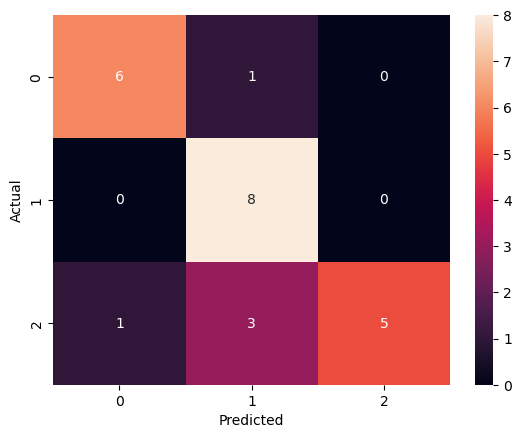

In [28]:
import seaborn as sns

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
#MODEL EVALUATION


score = model.evaluate(X_test, y_test, verbose=0)
accuracy = 100*score[1]

# print test accuracy
print('Test accuracy: %.4f%%' % accuracy)

Test accuracy: 79.1667%


In [27]:
#TESTING  MODEL ON NEW IMAGE
# Here i had given a image to test the image and predict the image. 


import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(228.5), np.float64(147.5), np.float64(-0.5))

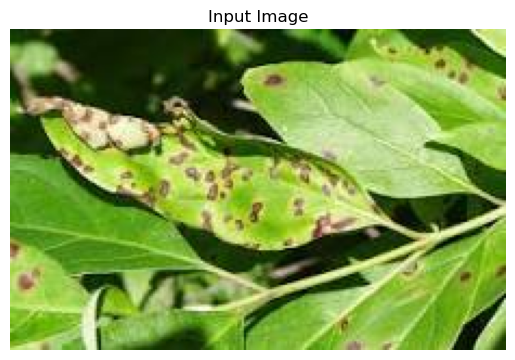

In [29]:
img_path = "test_leaf.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

In [30]:
img = cv2.resize(img,(128,128))

In [31]:
data = np.array(data)/255.0

In [32]:
img = np.reshape(img,(1,128,128,3))

In [33]:
prediction = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step


In [34]:
pred_class = np.argmax(prediction)

In [35]:
disease = laben.inverse_transform([pred_class])

print("Predicted Disease:", disease[0])

Predicted Disease: Leaf smut


In [ ]:
**PROJECT CONCLUSION**

Challenges Faced and Techniques Used

During the development of the rice leaf disease detection model, several challenges were encountered. 
Appropriate techniques were applied to overcome these issues and improve the performance of the model.

1. Small Dataset Size

Challenge:
The dataset used in this project contained only 120 images, with 40 images for each disease class. 
Such a small dataset may cause the model to memorize the training images instead of learning general patterns, 
leading to overfitting.

Technique Used:
To address this issue, data augmentation techniques such as rotation, zooming, flipping, and shearing were applied.
Data augmentation increases the diversity of the training dataset by generating modified versions of existing images, 
which helps the model learn better and improves generalization.

2. Overfitting

Challenge:
Due to the small dataset size, the model initially showed signs of overfitting, where the training accuracy was
high but validation accuracy was lower.

Technique Used:
A dropout layer was added to the neural network architecture. Dropout randomly disables a portion of neurons during training, 
which prevents the model from relying too heavily on specific features and helps improve generalization.

3. Image Variability

Challenge:
The images in the dataset had different lighting conditions, backgrounds, and orientations. These variations can affect 
the model's ability to learn consistent features.

Technique Used:
Image preprocessing steps such as image resizing, normalization, and standardizing image dimensions (128 × 128)
were applied to ensure consistent input for the model.

4. Feature Extraction from Images

Challenge:
Identifying subtle differences between similar rice leaf diseases can be difficult because some diseases 
have similar visual patterns.

Technique Used:
A Convolutional Neural Network (CNN) was implemented because CNNs are effective at automatically extracting 
    important visual features such as edges, textures, and patterns from images.

**Conclusion**

Despite the challenges related to dataset size and image variability, applying techniques such as data augmentation, 
dropout, and proper preprocessing helped improve the performance and reliability of the model. These techniques ensured 
that the model could learn meaningful patterns from the rice leaf images and perform accurate disease classification.

#Various challenges have face whether the data is small and it is in uneven in size, the following steps ara taken,
# Small dataset so used Data Augmentation.
# Dropout and Augmentation used for overfitting.
# Some images looked similar hence used CNN model to extract the various features.

**FINAL CONCLUSION**

# I had developed a project CNN based Rice leaf disease detection system.
# I had tested an sample image with 90% accuracy.